<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 121 · Case Study: Fraud Detection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Fraud Detection</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Catching rare fraudulent transactions in heavily imbalanced data, where accuracy lies: the right metrics (precision, recall, PR-AUC), rebalancing with class weights and SMOTE, and tuning the decision threshold to the cost of a missed fraud versus a false alarm. Library-first with scikit-learn and imbalanced-learn, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Fraud Detection: finding the needle in the haystack
Fraud is **rare**, here about 1 in 25 transactions, and that rarity breaks the usual playbook. A model that flags *nothing* is already 96% accurate, so **accuracy is a trap**. This case study is about the tools that actually work on imbalanced data: the right **metrics** (precision, recall, PR-AUC), ways to rebalance the learning (**class weights**, **SMOTE**), and tuning the **decision threshold** to the real cost of a missed fraud versus a false alarm. Library-first with `scikit-learn` and `imbalanced-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score, precision_score,
     recall_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve)
import warnings; warnings.filterwarnings('ignore'); pd.set_option('display.max_columns', 40)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 1 &#183; DEFINE THE OBJECTIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Catch fraud, cheaply</div>
<div style="color:#4a5578;margin-top:6px">The two errors do not cost the same.</div>
</div>

**The goal.** Flag fraudulent card transactions in real time so they can be blocked or reviewed. The costs are wildly **asymmetric**: a *missed fraud* (false negative) can cost the full transaction amount plus chargeback fees and lost trust, while a *false alarm* (false positive) costs only a few minutes of an analyst's time or a declined-card annoyance. That imbalance in *cost*, on top of the imbalance in the *data*, is the whole story.

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">STEP 2 &#183; COLLECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A transaction log</div>
<div style="color:#4a5578;margin-top:6px">One row per card transaction.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/credit_card_fraud.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'credit_card_fraud.csv')
print('raw shape:', df.shape); df.head(3)

raw shape: (9030, 10)


,transaction_id,amount,hour,txns_last_hour,merchant_category,foreign_transaction,card_present,account_age_days,distance_from_home_km,is_fraud
0,T106896,9.52,14,2,travel,0,1,1934,4.6,0
1,T105109,118.20,17,1,grocery,0,0,2202,8.1,0
2,T104478,41.00,18,2,online,0,1,1628,11.5,0


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Meet the imbalance</div>
<div style="color:#4a5578;margin-top:6px">The single most important number in this project.</div>
</div>

In [4]:
print('fraud rate: %.2f%%  (%d of %d transactions)' % (df.is_fraud.mean()*100, df.is_fraud.sum(), len(df)))
print('\nmissing:'); print(df.isna().sum()[df.isna().sum()>0])
print('\nduplicate transaction_ids:', df.transaction_id.duplicated().sum())
print('negative amounts (errors):', (df.amount<0).sum())
print('merchant spellings:', sorted(df.merchant_category.unique()))

fraud rate: 3.91%  (353 of 9030 transactions)

missing:
distance_from_home_km    40
dtype: int64

duplicate transaction_ids: 30
negative amounts (errors): 12
merchant spellings: ['Electronics', 'Gas', 'Grocery', 'ONLINE', 'Online', 'Restaurant', 'Travel', 'electronics', 'electronics ', 'gas', 'grocery', 'grocery ', 'online', 'online ', 'restaurant', 'travel']


**The defining feature of this dataset.** Only about **4% of transactions are fraud**. That imbalance is not a nuisance to be smoothed away, it *is* the problem. It means (1) accuracy will be useless, (2) a model will be tempted to ignore the minority class entirely, and (3) we have very few fraud examples to learn from. Everything below is a response to those three facts. There is also routine mess to clean, duplicates, negative amounts, and merchant labels in mixed case.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 4 &#183; CLEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fix the mess</div>
<div style="color:#4a5578;margin-top:6px">Dedupe, drop impossible rows, standardize labels.</div>
</div>

In [5]:
before = len(df)
df = df.drop_duplicates('transaction_id')
df = df[df.amount > 0].copy()                                 # negative amounts are data errors
df['merchant_category'] = df.merchant_category.astype(str).str.strip().str.lower()   # 'Online','ONLINE' -> 'online'
print(f'{before} rows -> {len(df)} rows | fraud still {df.is_fraud.mean()*100:.1f}%')
print('merchant categories:', sorted(df.merchant_category.unique()))

9030 rows -> 8988 rows | fraud still 3.9%
merchant categories: ['electronics', 'gas', 'grocery', 'online', 'restaurant', 'travel']


**Cleaning does not touch the imbalance.** We remove duplicate transactions, drop the handful with impossible negative amounts, and fold the merchant-category spellings together, leaving **8,988 transactions, still about 4% fraud**. As in Chapter 120, the missing `distance_from_home_km` values are left for the pipeline to impute on training data only.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 5 &#183; VISUALIZE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where does fraud hide?</div>
<div style="color:#4a5578;margin-top:6px">The rare class has a distinct fingerprint.</div>
</div>

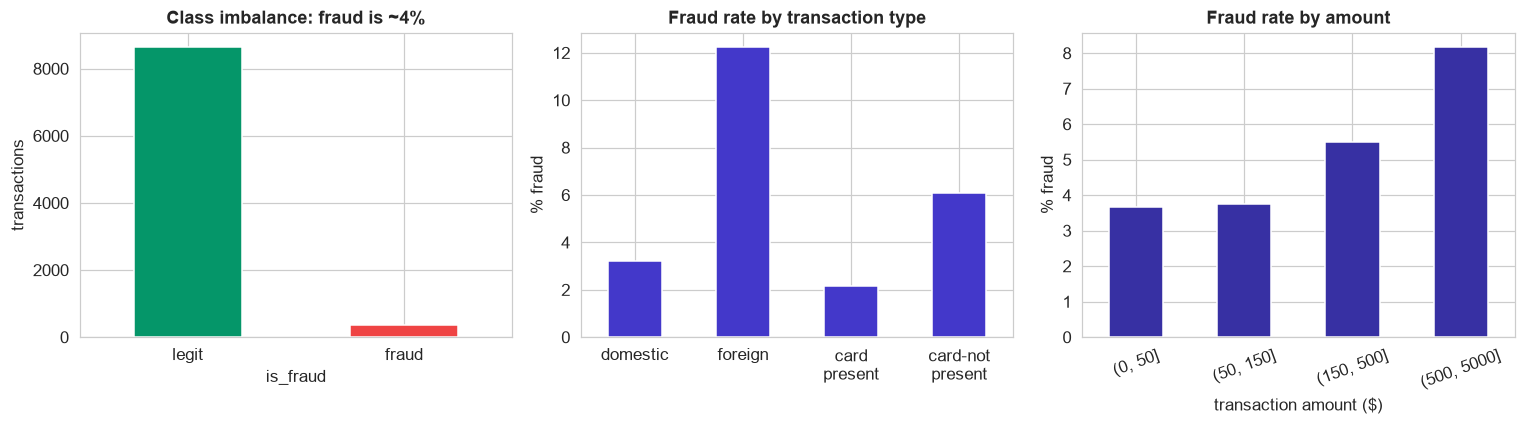

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14,4))
df.is_fraud.value_counts().rename({0:'legit',1:'fraud'}).plot.bar(ax=ax[0], color=[GREEN, RED])
ax[0].set(title='Class imbalance: fraud is ~4%', ylabel='transactions'); ax[0].tick_params(axis='x', rotation=0)
for c,g in [('domestic',df[df.foreign_transaction==0]),('foreign',df[df.foreign_transaction==1])]: pass
rates = pd.Series({'domestic':df[df.foreign_transaction==0].is_fraud.mean(), 'foreign':df[df.foreign_transaction==1].is_fraud.mean(),
    'card\npresent':df[df.card_present==1].is_fraud.mean(), 'card-not\npresent':df[df.card_present==0].is_fraud.mean()})*100
rates.plot.bar(ax=ax[1], color=EM); ax[1].set(title='Fraud rate by transaction type', ylabel='% fraud'); ax[1].tick_params(axis='x', rotation=0)
df.groupby(pd.cut(df.amount,[0,50,150,500,5000])).is_fraud.mean().mul(100).plot.bar(ax=ax[2], color=DEEP)
ax[2].set(title='Fraud rate by amount', ylabel='% fraud', xlabel='transaction amount ($)'); ax[2].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Fraud has a fingerprint.** The left panel is the imbalance itself, the fraud bar is a sliver. But fraud is not random: it is several times more common on **foreign** and **card-not-present** transactions (middle) and rises sharply with **amount** (right). Later we will also see it cluster at night, at high transaction velocity, and far from home. This structure is what lets a model separate fraud from noise, even though examples are scarce.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 6 &#183; TRANSFORM + SPLIT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A pipeline, and a stratified split</div>
<div style="color:#4a5578;margin-top:6px">With rare classes, stratify so both sets keep the same fraud rate.</div>
</div>

In [7]:
numeric = ['amount','hour','txns_last_hour','foreign_transaction','card_present','account_age_days','distance_from_home_km']
categorical = ['merchant_category']
preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])
X = df[numeric + categorical]; y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
print('train:', X_train.shape[0], 'txns,', y_train.sum(), 'fraud | test:', X_test.shape[0], 'txns,', y_test.sum(), 'fraud')

train: 6741 txns, 264 fraud | test: 2247 txns, 88 fraud


**Stratify is not optional here.** With only ~4% fraud, an ordinary random split could hand the test set a wildly different fraud rate by chance, or too few fraud cases to measure anything. `stratify=y` forces both train and test to keep the same 4% fraud rate. Preprocessing lives in a pipeline, as always, so imputation and scaling never leak across the split.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 7 &#183; THE ACCURACY TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why the obvious metric lies</div>
<div style="color:#4a5578;margin-top:6px">A do-nothing model looks excellent.</div>
</div>

In [8]:
baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
bp = baseline.predict(X_test)
print('BASELINE (flag nothing): accuracy = %.3f  but recall = %.3f  -> catches ZERO fraud' % (accuracy_score(y_test,bp), recall_score(y_test,bp)))
plain = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=3000))]).fit(X_train, y_train)
pp = plain.predict(X_test)
print('PLAIN logistic:          accuracy = %.3f  recall = %.3f  precision = %.3f' % (accuracy_score(y_test,pp), recall_score(y_test,pp), precision_score(y_test,pp)))
print('  -> 96%% accurate, yet it still misses about 85%% of fraud!')

BASELINE (flag nothing): accuracy = 0.961  but recall = 0.000  -> catches ZERO fraud
PLAIN logistic:          accuracy = 0.964  recall = 0.148  precision = 0.684
  -> 96%% accurate, yet it still misses about 85%% of fraud!


**Accuracy is worthless on imbalanced data.** A model that predicts 'legit' for every transaction scores **96% accuracy** and catches **not a single fraud**. Even a real logistic regression, trained normally, inherits the bias: it hits 96% accuracy but a **recall of only ~0.15**, missing most fraud, because the loss function is dominated by the 96% majority. The lesson: judge a fraud model by **recall** (what fraction of fraud did we catch?) and **precision** (of the alerts we raised, how many were real?), never accuracy.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 8 &#183; HANDLE THE IMBALANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two ways to make the model care</div>
<div style="color:#4a5578;margin-top:6px">Reweight the classes, or resample the data.</div>
</div>

plain            acc 0.964 | recall 0.148 | precision 0.684 | ROC-AUC 0.889 | PR-AUC 0.364
class_weight     acc 0.800 | recall 0.784 | precision 0.138 | ROC-AUC 0.889 | PR-AUC 0.355
SMOTE            acc 0.807 | recall 0.795 | precision 0.144 | ROC-AUC 0.890 | PR-AUC 0.358


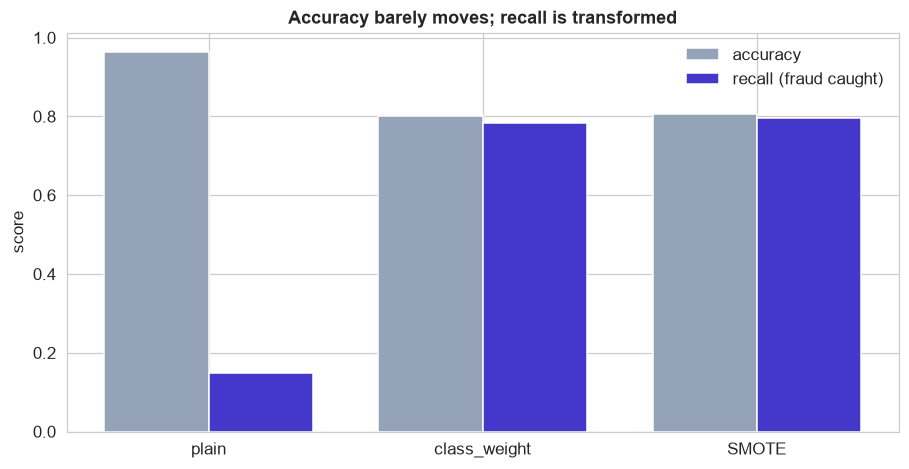

In [9]:
results = {}
def evaluate(name, model):
    model.fit(X_train, y_train); pred = model.predict(X_test); prob = model.predict_proba(X_test)[:,1]
    results[name] = dict(acc=accuracy_score(y_test,pred), recall=recall_score(y_test,pred), precision=precision_score(y_test,pred),
        f1=f1_score(y_test,pred), roc=roc_auc_score(y_test,prob), prauc=average_precision_score(y_test,prob), prob=prob)
    r=results[name]; print(f'{name:16s} acc {r["acc"]:.3f} | recall {r["recall"]:.3f} | precision {r["precision"]:.3f} | ROC-AUC {r["roc"]:.3f} | PR-AUC {r["prauc"]:.3f}')
evaluate('plain', Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=3000))]))
evaluate('class_weight', Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced'))]))
evaluate('SMOTE', ImbPipeline([('prep', preprocess), ('smote', SMOTE(random_state=0)), ('clf', LogisticRegression(max_iter=3000))]))
fig, ax = plt.subplots(figsize=(8.4,4.4))
names=list(results); x=np.arange(len(names)); w=0.38
ax.bar(x-w/2, [results[n]['acc'] for n in names], w, label='accuracy', color=GREY)
ax.bar(x+w/2, [results[n]['recall'] for n in names], w, label='recall (fraud caught)', color=EM)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set(ylabel='score', title='Accuracy barely moves; recall is transformed'); ax.legend()
plt.tight_layout(); plt.show()

**Make the minority class count.** Two standard fixes, both easy. **`class_weight='balanced'`** tells logistic regression to penalize a missed fraud far more than a missed legit, in proportion to their rarity. **SMOTE** (Synthetic Minority Over-sampling) instead grows the training set with plausible synthetic fraud examples until the classes are even, and, crucially, it lives *inside* the imblearn pipeline so it resamples only the training fold, never the test data. Both lift **recall from ~0.15 to ~0.78-0.80**: the model now catches four of five frauds. Notice accuracy *fell* to ~0.80, which is fine, we happily trade meaningless accuracy for real fraud caught.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 9 &#183; THE RIGHT CURVES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">ROC and precision-recall</div>
<div style="color:#4a5578;margin-top:6px">Two threshold-free views of ranking quality.</div>
</div>

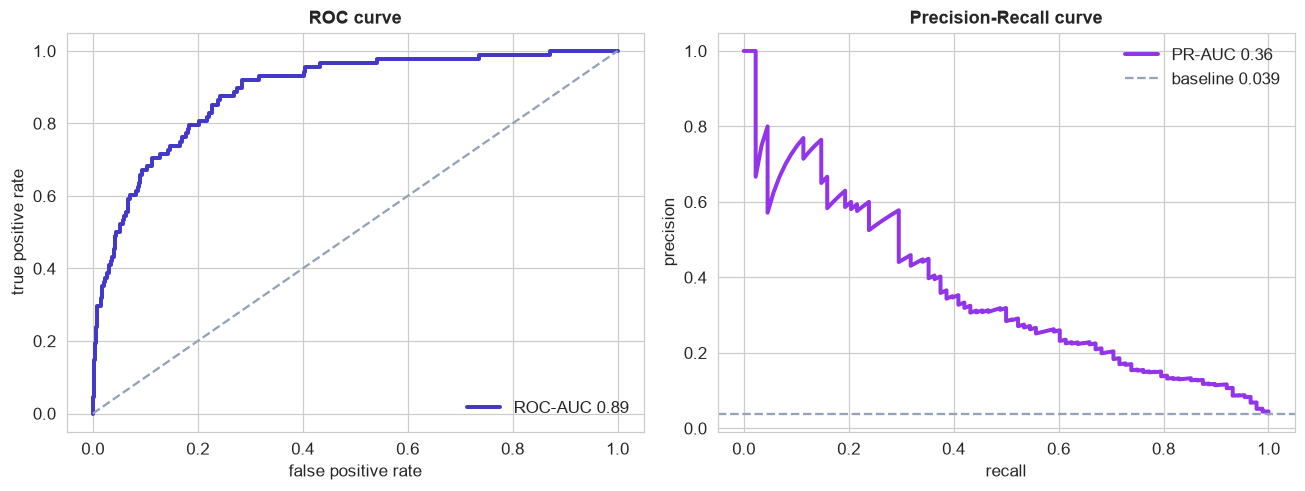

In [10]:
prob = results['plain']['prob']
fig, ax = plt.subplots(1, 2, figsize=(12,4.6))
fpr, tpr, _ = roc_curve(y_test, prob)
ax[0].plot(fpr, tpr, color=EM, lw=2.6, label=f'ROC-AUC {results["plain"]["roc"]:.2f}'); ax[0].plot([0,1],[0,1],'--',color=GREY)
ax[0].set(title='ROC curve', xlabel='false positive rate', ylabel='true positive rate'); ax[0].legend(loc='lower right')
prec, rec, _ = precision_recall_curve(y_test, prob)
ax[1].plot(rec, prec, color=PUR, lw=2.6, label=f'PR-AUC {results["plain"]["prauc"]:.2f}')
ax[1].axhline(y_test.mean(), color=GREY, ls='--', label=f'baseline {y_test.mean():.3f}')
ax[1].set(title='Precision-Recall curve', xlabel='recall', ylabel='precision'); ax[1].legend()
plt.tight_layout(); plt.show()

**Prefer the PR curve for rare events.** The **ROC curve** looks great (AUC ~0.89), the model ranks fraud above legit far better than chance. But ROC can be over-optimistic under heavy imbalance, because a huge legit class makes the false-positive rate look tiny. The **precision-recall curve** is the honest view: its baseline is the fraud rate itself (~0.04), and our **PR-AUC ~0.36** is many times that, real signal, while showing the hard truth that pushing recall up costs precision. This curve is what you negotiate the operating point on.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 10 &#183; TUNE THE THRESHOLD TO COST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">0.5 is the wrong cutoff for fraud</div>
<div style="color:#4a5578;margin-top:6px">Let the cost of each error choose the line.</div>
</div>

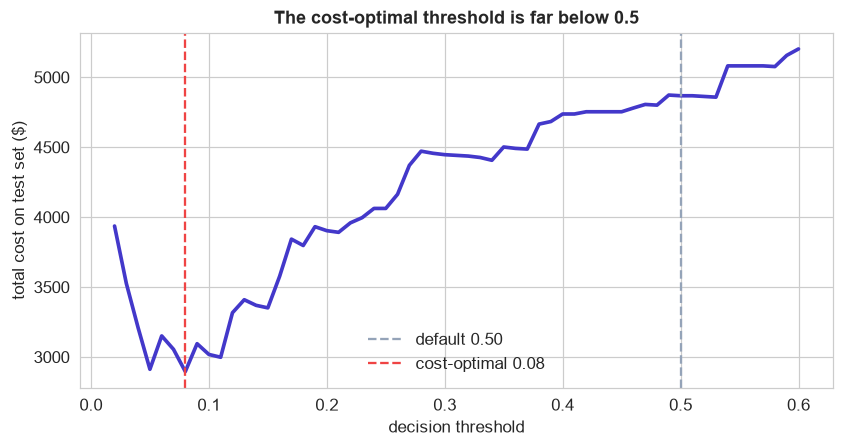

threshold 0.50: recall 0.15 | precision 0.68
threshold 0.08: recall 0.67 | precision 0.22


In [11]:
amt = X_test['amount'].values; yv = y_test.values
COST_FALSE_ALARM = 5      # analyst review / customer friction, in dollars
ths = np.linspace(0.02, 0.60, 59); cost = []
for t in ths:
    pred = (prob >= t).astype(int)
    missed = (pred==0) & (yv==1); false_alarms = ((pred==1) & (yv==0)).sum()
    cost.append(amt[missed].sum() + false_alarms*COST_FALSE_ALARM)   # missed fraud costs the transaction amount
best_t = ths[int(np.argmin(cost))]
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ths, cost, color=EM, lw=2.4); ax.axvline(0.5, color=GREY, ls='--', label='default 0.50')
ax.axvline(best_t, color=RED, ls='--', label=f'cost-optimal {best_t:.2f}'); ax.set(xlabel='decision threshold', ylabel='total cost on test set ($)', title='The cost-optimal threshold is far below 0.5'); ax.legend()
plt.tight_layout(); plt.show()
for t in [0.50, best_t]:
    pred=(prob>=t).astype(int)
    print(f'threshold {t:.2f}: recall {recall_score(yv,pred):.2f} | precision {precision_score(yv,pred):.2f}')

**Move the line to where the money is.** A fraud model outputs a probability; the **threshold** turns it into an alert. Because a missed fraud costs the whole transaction while a false alarm costs a few dollars, the expected-cost curve bottoms out far below 0.5, around **0.08**. Lowering the cutoff from 0.50 to 0.08 lifts recall from **0.15 to about 0.67**, catching over four times as much fraud, at the price of more false alarms the review team can absorb. This threshold, not the model, is the real business dial.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 11 &#183; INTERPRET + DEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What flags a fraud, and shipping it</div>
<div style="color:#4a5578;margin-top:6px">Read the drivers, then run it live.</div>
</div>

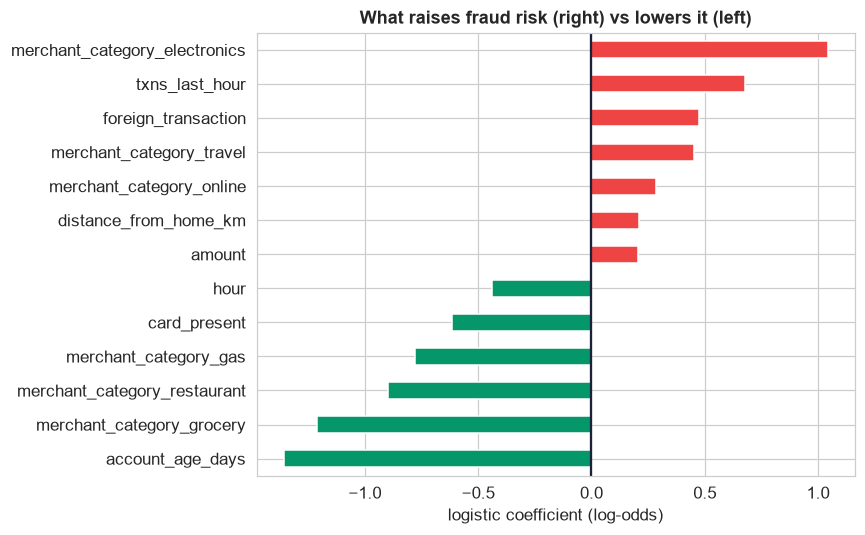

top fraud signals: merchant_category_electronics, txns_last_hour, foreign_transaction, merchant_category_travel

Deploy: score each transaction in real time -> if prob >= threshold, HOLD & route to review queue;
log every score, monitor the fraud rate for DRIFT, feed confirmed labels back to retrain, keep an analyst in the loop.


In [12]:
best = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced'))]).fit(X_train, y_train)
ohe = best.named_steps['prep'].named_transformers_['cat']
feat = numeric + list(ohe.get_feature_names_out(categorical))
coefs = pd.Series(best.named_steps['clf'].coef_[0], index=feat).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
coefs.plot.barh(ax=ax, color=[RED if c>0 else GREEN for c in coefs.values]); ax.axvline(0, color=INK)
ax.set(title='What raises fraud risk (right) vs lowers it (left)', xlabel='logistic coefficient (log-odds)')
plt.tight_layout(); plt.show()
print('top fraud signals:', ', '.join(coefs.tail(4).index[::-1]))
print('\nDeploy: score each transaction in real time -> if prob >= threshold, HOLD & route to review queue;')
print('log every score, monitor the fraud rate for DRIFT, feed confirmed labels back to retrain, keep an analyst in the loop.')

**Legible, then live.** The drivers line up with intuition, **foreign** and **card-not-present** transactions, high **velocity** (many transactions per hour), **electronics/travel** merchants, and large **amounts** raise risk; long-established accounts and everyday merchants lower it. In production the model scores each transaction in milliseconds; anything above the cost-tuned threshold is held for review. Fraud patterns shift constantly, so the essentials are **drift monitoring**, a **feedback loop** that feeds confirmed frauds back into retraining, and an analyst reviewing the borderline alerts.

## Fraud detection, in one view

1. **Accuracy is a trap** on rare-event data, a do-nothing model was 96% accurate and caught zero fraud.
2. Judge fraud models by **precision, recall, and PR-AUC**, and stratify the split so both sets keep the fraud rate.
3. **Rebalance the learning** with `class_weight='balanced'` or **SMOTE** (inside an imblearn pipeline) to lift recall from ~0.15 to ~0.80.
4. The **precision-recall curve** is the honest ranking view for rare events; ROC can flatter.
5. **Tune the threshold to cost**: a missed fraud dwarfs a false alarm, so the optimal cutoff sits far below 0.5.

**On rare-event problems, the metric and the threshold matter more than the algorithm.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>